# Load the repositories to compare, and split them into their developer and agent groups

In [1]:
import pandas as pd
import numpy as np

import os
import warnings
warnings.filterwarnings('ignore')


from pathlib import Path

DATA_PATH = (
    Path.cwd().parent.parent
    / 'dataset'
    / 'data'
    / 'final_dataset_new_corrected.csv'
)


OUT_DIR   = os.path.join(os.getcwd(), 'dataset_comparability','outputs')
os.makedirs(OUT_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)

df = df_raw[['repo', 'group']].copy()

df_agentic = df[df['group'] == 'agent'].copy().drop_duplicates()

df_developer = df[df['group'] == 'human'].copy().drop_duplicates()

print(f"Number of unique repositories in agentic group: {len(df_agentic['repo'].unique())}")    
print(f"Number of unique repositories in developer group: {len(df_developer['repo'].unique())}")


Number of unique repositories in agentic group: 260
Number of unique repositories in developer group: 252


In [2]:

# ── Fetch repository metadata from GitHub API (cached) ───────────────────────
import requests, json, time, re
from pathlib import Path

try:
    from dotenv import load_dotenv
    load_dotenv(Path.cwd().parent.parent / '.env')
    GITHUB_TOKEN = os.getenv('GITHUB_TOKEN_1', '')
except ImportError:
    _env = Path.cwd().parent.parent / '.env'
    GITHUB_TOKEN = ''
    if _env.exists():
        for _l in _env.read_text().splitlines():
            if _l.startswith('GITHUB_TOKEN_1='):
                GITHUB_TOKEN = _l.split('=', 1)[1].strip()
                break

HEADERS = {'Authorization': f'token {GITHUB_TOKEN}',
           'Accept': 'application/vnd.github.v3+json'}
CACHE_FILE = Path(OUT_DIR) / 'repo_metadata_cache.json'


def _gh_get(url, params=None):
    """GET with automatic rate-limit back-off."""
    for _ in range(5):
        r = requests.get(url, headers=HEADERS, params=params, timeout=30)
        if r.status_code in (403, 429):
            wait = int(r.headers.get('Retry-After', 60)) + 5
            print(f"  Rate-limited — sleeping {wait}s …")
            time.sleep(wait)
            continue
        return r
    return r


def _json(r, fallback=None):
    """Parse response JSON; return fallback on any decode error."""
    try:
        return r.json()
    except Exception:
        return fallback


def _api_url(repo_url):
    """Normalise github.com URLs to the REST API endpoint."""
    return repo_url.replace('https://github.com/', 'https://api.github.com/repos/')


def fetch_repo_meta(repo_url):
    """Return a dict of repo characteristics, or None if unavailable."""
    api = _api_url(repo_url)
    r = _gh_get(api)
    if not r.ok:
        return None
    d = _json(r)
    if d is None:
        return None

    # Language byte-counts
    lr = _gh_get(api + '/languages')
    languages = _json(lr, {}) if lr.ok else {}
    time.sleep(0.1)

    # Contributor count via Link header
    cr = _gh_get(api + '/contributors', params={'per_page': 1, 'anon': 1})
    if cr.ok:
        m = re.search(r'page=(\d+)>; rel="last"', cr.headers.get('Link', ''))
        contributor_count = int(m.group(1)) if m else len(_json(cr, []))
    else:
        contributor_count = 0
    time.sleep(0.1)

    # Merge rate: merged PRs / all PRs (search API, 30 req/min)
    owner_repo = api.split('repos/')[-1]
    sr_merged = _gh_get('https://api.github.com/search/issues',
                         params={'q': f'repo:{owner_repo} is:pr is:merged', 'per_page': 1})
    sr_total  = _gh_get('https://api.github.com/search/issues',
                         params={'q': f'repo:{owner_repo} is:pr', 'per_page': 1})
    merge_rate = None
    if sr_merged.ok and sr_total.ok:
        d_merged = _json(sr_merged, {})
        d_total  = _json(sr_total,  {})
        total_n  = d_total.get('total_count', 0)
        merged_n = d_merged.get('total_count', 0)
        merge_rate = merged_n / total_n if total_n > 0 else None
    time.sleep(2.5)  # search API: 30 req/min with token

    return {
        'stars':             d.get('stargazers_count', 0),
        'forks':             d.get('forks_count', 0),
        'size_kb':           d.get('size', 0),
        'primary_language':  d.get('language') or 'Unknown',
        'open_issues':       d.get('open_issues_count', 0),
        'created_at':        d.get('created_at', ''),
        'topics':            d.get('topics', []),
        'subscribers':       d.get('subscribers_count', 0),
        'license':           (d.get('license') or {}).get('spdx_id', 'NOASSERTION'),
        'archived':          d.get('archived', False),
        'languages':         languages,
        'contributor_count': contributor_count,
        'merge_rate':        merge_rate,
    }


def _fetch_batch(urls, label):
    for i, url in enumerate(urls, 1):
        repo_meta[url] = fetch_repo_meta(url)
        if i % 10 == 0 or i == len(urls):
            print(f"  [{i}/{len(urls)}]  {url.split('/')[-2]}/{url.split('/')[-1]}")
            CACHE_FILE.write_text(json.dumps(repo_meta, indent=2))


# ── Load existing cache ──────────────────────────────────────────────────────
repo_meta = {}
if CACHE_FILE.exists():
    repo_meta = json.loads(CACHE_FILE.read_text())
    print(f"Cache loaded: {len(repo_meta)} entries  "
          f"({sum(1 for v in repo_meta.values() if v)} non-null)")

all_repos = sorted(
    set(df_agentic['repo'].unique()) | set(df_developer['repo'].unique())
)

# ── 1. Fetch repos not yet in cache ──────────────────────────────────────────
missing = [r for r in all_repos if r not in repo_meta]
if missing:
    print(f"\nFetching {len(missing)} new repos…")
    _fetch_batch(missing, 'new')

# ── 2. Re-fetch repos stored as null (e.g. github.com URLs fetched before fix)
null_repos = [r for r in all_repos if repo_meta.get(r) is None]
if null_repos:
    print(f"\nRe-fetching {len(null_repos)} null repos (URL normalisation fix)…")
    _fetch_batch(null_repos, 're-fetch')

# ── 3. Backfill merge_rate for cached repos missing it ───────────────────────
needs_merge = [url for url, v in repo_meta.items() if v and 'merge_rate' not in v]
if needs_merge:
    print(f"\nBackfilling merge_rate for {len(needs_merge)} repos…")
    for i, url in enumerate(needs_merge, 1):
        owner_repo = _api_url(url).split('repos/')[-1]
        sr_m = _gh_get('https://api.github.com/search/issues',
                        params={'q': f'repo:{owner_repo} is:pr is:merged', 'per_page': 1})
        sr_t = _gh_get('https://api.github.com/search/issues',
                        params={'q': f'repo:{owner_repo} is:pr', 'per_page': 1})
        time.sleep(2.5)
        if sr_m.ok and sr_t.ok:
            d_m, d_t = _json(sr_m, {}), _json(sr_t, {})
            total_n  = d_t.get('total_count', 0)
            merged_n = d_m.get('total_count', 0)
            repo_meta[url]['merge_rate'] = merged_n / total_n if total_n > 0 else None
        else:
            repo_meta[url]['merge_rate'] = None
        if i % 20 == 0 or i == len(needs_merge):
            print(f"  [{i}/{len(needs_merge)}]")
            CACHE_FILE.write_text(json.dumps(repo_meta, indent=2))

CACHE_FILE.write_text(json.dumps(repo_meta, indent=2))
valid = sum(1 for v in repo_meta.values() if v)
print(f"\nDone — {valid}/{len(repo_meta)} repos have data")


Cache loaded: 512 entries  (257 non-null)

Re-fetching 255 null repos (URL normalisation fix)…
  [10/255]  Cxbx-Reloaded/Cxbx-Reloaded
  [20/255]  FuelRats/pipsqueak3
  [30/255]  LSSTDESC/descqa
  [40/255]  OpenLightingProject/open-fixture-library
  [50/255]  RedHatInsights/settings-frontend
  [60/255]  UNN-ITMM-Software/agile-course-practice-2019
  [70/255]  andela/denethor-ah-frontend
  [80/255]  awesome-academy/php_oe28_lab_lm
  [90/255]  cerner/carbon-graphs
  [100/255]  deltachat/deltachat-desktop
  [110/255]  efrainva/Sprint-Challenge--Intro-Python
  [120/255]  fossasia/susi_iOS
  [130/255]  googleinterns/step227-2020
  [140/255]  hrr40-fec2/Photo-Carousel
  [150/255]  karllark/measure_extinction
  [160/255]  microsoft/terminal
  [170/255]  netdata/netdata
  [180/255]  osudroid/osu-droid
  [190/255]  ppy/osu-web
  [200/255]  r-spatial/sf
  [210/255]  scala/scala
  [220/255]  sot/proseco
  [230/255]  sxs-collaboration/spectre
  [240/255]  uchicago-mobi/mpcs501030-2020-winter-assig

In [3]:

# ── Build per-group DataFrames ───────────────────────────────────────────────
from datetime import datetime, timezone
from scipy import stats as sp_stats

if 'repo_meta' not in globals() or not repo_meta:
    raise RuntimeError("repo_meta is empty — run Cell 2 first.")

REF_DATE = datetime.now(timezone.utc)

META_COLS = ['repo', 'group', 'stars', 'forks', 'size_kb', 'primary_language',
             'open_issues', 'contributor_count', 'age_days', 'age_at_pr_days',
             'num_topics', 'num_languages', 'subscribers', 'merge_rate',
             'license', 'archived']

def build_meta_df(repo_urls, group):
    rows = []
    for url in repo_urls:
        m = repo_meta.get(url)
        if not m:
            continue

        # Repo age (current)
        age_days = None
        repo_created_ts = None
        if m.get('created_at'):
            repo_created_ts = pd.to_datetime(m['created_at'], utc=True)
            age_days = (REF_DATE - repo_created_ts.to_pydatetime()).days

        # Project age at time of PR (median across all PRs in dataset for this repo)
        age_at_pr_days = None
        if repo_created_ts is not None:
            repo_prs = df_raw[df_raw['repo'] == url]['pr_date_created']
            pr_dates = pd.to_datetime(repo_prs, utc=True, errors='coerce').dropna()
            if not pr_dates.empty:
                age_at_pr_days = float(
                    (pr_dates - repo_created_ts).dt.days.median()
                )

        rows.append({
            'repo':              url,
            'group':             group,
            'stars':             m['stars'],
            'forks':             m['forks'],
            'size_kb':           m['size_kb'],
            'primary_language':  m['primary_language'],
            'open_issues':       m['open_issues'],
            'contributor_count': m['contributor_count'],
            'age_days':          age_days,
            'age_at_pr_days':    age_at_pr_days,
            'num_topics':        len(m.get('topics', [])),
            'num_languages':     len(m.get('languages', {})),
            'subscribers':       m['subscribers'],
            'merge_rate':        m.get('merge_rate'),
            'license':           m['license'],
            'archived':          m['archived'],
        })

    if not rows:
        return pd.DataFrame(columns=META_COLS)
    return pd.DataFrame(rows)

agent_urls = df_agentic['repo'].unique()
dev_urls   = df_developer['repo'].unique()

df_agent_meta = build_meta_df(agent_urls, 'agent')
df_dev_meta   = build_meta_df(dev_urls,   'developer')

# Diagnostic — flag if many repos are missing from the cache
agent_missing = sum(1 for u in agent_urls if not repo_meta.get(u))
dev_missing   = sum(1 for u in dev_urls   if not repo_meta.get(u))
if agent_missing or dev_missing:
    print(f"⚠  Repos not found in cache — agent: {agent_missing}, developer: {dev_missing}")
    print("   These repos will be excluded from comparisons (deleted/private/fetch failed).")

df_meta = pd.concat([df_agent_meta, df_dev_meta], ignore_index=True)

NUMERIC = ['stars', 'forks', 'size_kb', 'open_issues',
           'contributor_count', 'age_days', 'age_at_pr_days',
           'num_topics', 'num_languages', 'subscribers', 'merge_rate']

print(f"Repos with metadata — agent: {len(df_agent_meta)}, developer: {len(df_dev_meta)}\n")
print("Median per group:")
print(df_meta.groupby('group')[NUMERIC].median().round(3).T.to_string())


# ── Mann-Whitney U + Cliff's delta ───────────────────────────────────────────
def cliffs_delta(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return (np.sum(a[:, None] > b) - np.sum(a[:, None] < b)) / (len(a) * len(b))

def effect_label(d):
    d = abs(d)
    if d < 0.147: return 'negligible'
    if d < 0.330: return 'small'
    if d < 0.474: return 'medium'
    return 'large'

stat_rows = []
for col in NUMERIC:
    a = df_agent_meta[col].dropna().values
    b = df_dev_meta[col].dropna().values
    _, p = sp_stats.mannwhitneyu(a, b, alternative='two-sided')
    cd = cliffs_delta(a, b)
    stat_rows.append({
        'Metric':         col.replace('_', ' ').title(),
        'Agent Median':   float(np.median(a)),
        'Dev Median':     float(np.median(b)),
        'p (MWU)':        p,
        "Cliff's δ":      cd,
        'Effect':         effect_label(cd),
        'sig':            p < 0.05,
    })

df_stats = pd.DataFrame(stat_rows)
df_stats['p (Bonferroni)'] = (df_stats['p (MWU)'] * len(NUMERIC)).clip(upper=1.0)
df_stats['sig_bonf'] = df_stats['p (Bonferroni)'] < 0.05


# ── Language distribution: chi-squared ──────────────────────────────────────
lang_table = (df_meta.groupby(['group', 'primary_language'])
              .size().unstack(fill_value=0))
chi2_lang, p_lang, dof_lang, _ = sp_stats.chi2_contingency(lang_table)


# ── Print results table ──────────────────────────────────────────────────────
print("\nMann-Whitney U Tests + Cliff's Delta (agent vs developer repos)")
print("─" * 80)
display_df = df_stats[['Metric', 'Agent Median', 'Dev Median',
                        'p (MWU)', 'p (Bonferroni)', "Cliff's δ", 'Effect', 'sig']].copy()
display_df['sig'] = display_df['sig'].map({True: '*', False: ''})
display_df = display_df.rename(columns={'sig': 'Sig.'})
print(display_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f"\nLanguage distribution: χ²({dof_lang}) = {chi2_lang:.2f}, "
      f"p = {p_lang:.4f}  {'*' if p_lang < 0.05 else '(n.s.)'}")

df_stats.to_csv(Path(OUT_DIR) / 'comparability_stats.csv', index=False)
print(f"\nResults saved → comparability_stats.csv")


⚠  Repos not found in cache — agent: 3, developer: 1
   These repos will be excluded from comparisons (deleted/private/fetch failed).
Repos with metadata — agent: 257, developer: 251

Median per group:
group                 agent  developer
stars                 0.000    111.000
forks                 0.000     49.000
size_kb            2266.000  18853.000
open_issues           2.000     28.000
contributor_count     2.000     32.000
age_days            367.000   3173.000
age_at_pr_days       19.000    539.000
num_topics            0.000      3.000
num_languages         4.000      4.000
subscribers           0.000     11.000
merge_rate            0.865      0.847

Mann-Whitney U Tests + Cliff's Delta (agent vs developer repos)
────────────────────────────────────────────────────────────────────────────────
           Metric  Agent Median  Dev Median  p (MWU)  p (Bonferroni)  Cliff's δ     Effect Sig.
            Stars        0.0000    111.0000   0.0000          0.0000    -0.6317      lar

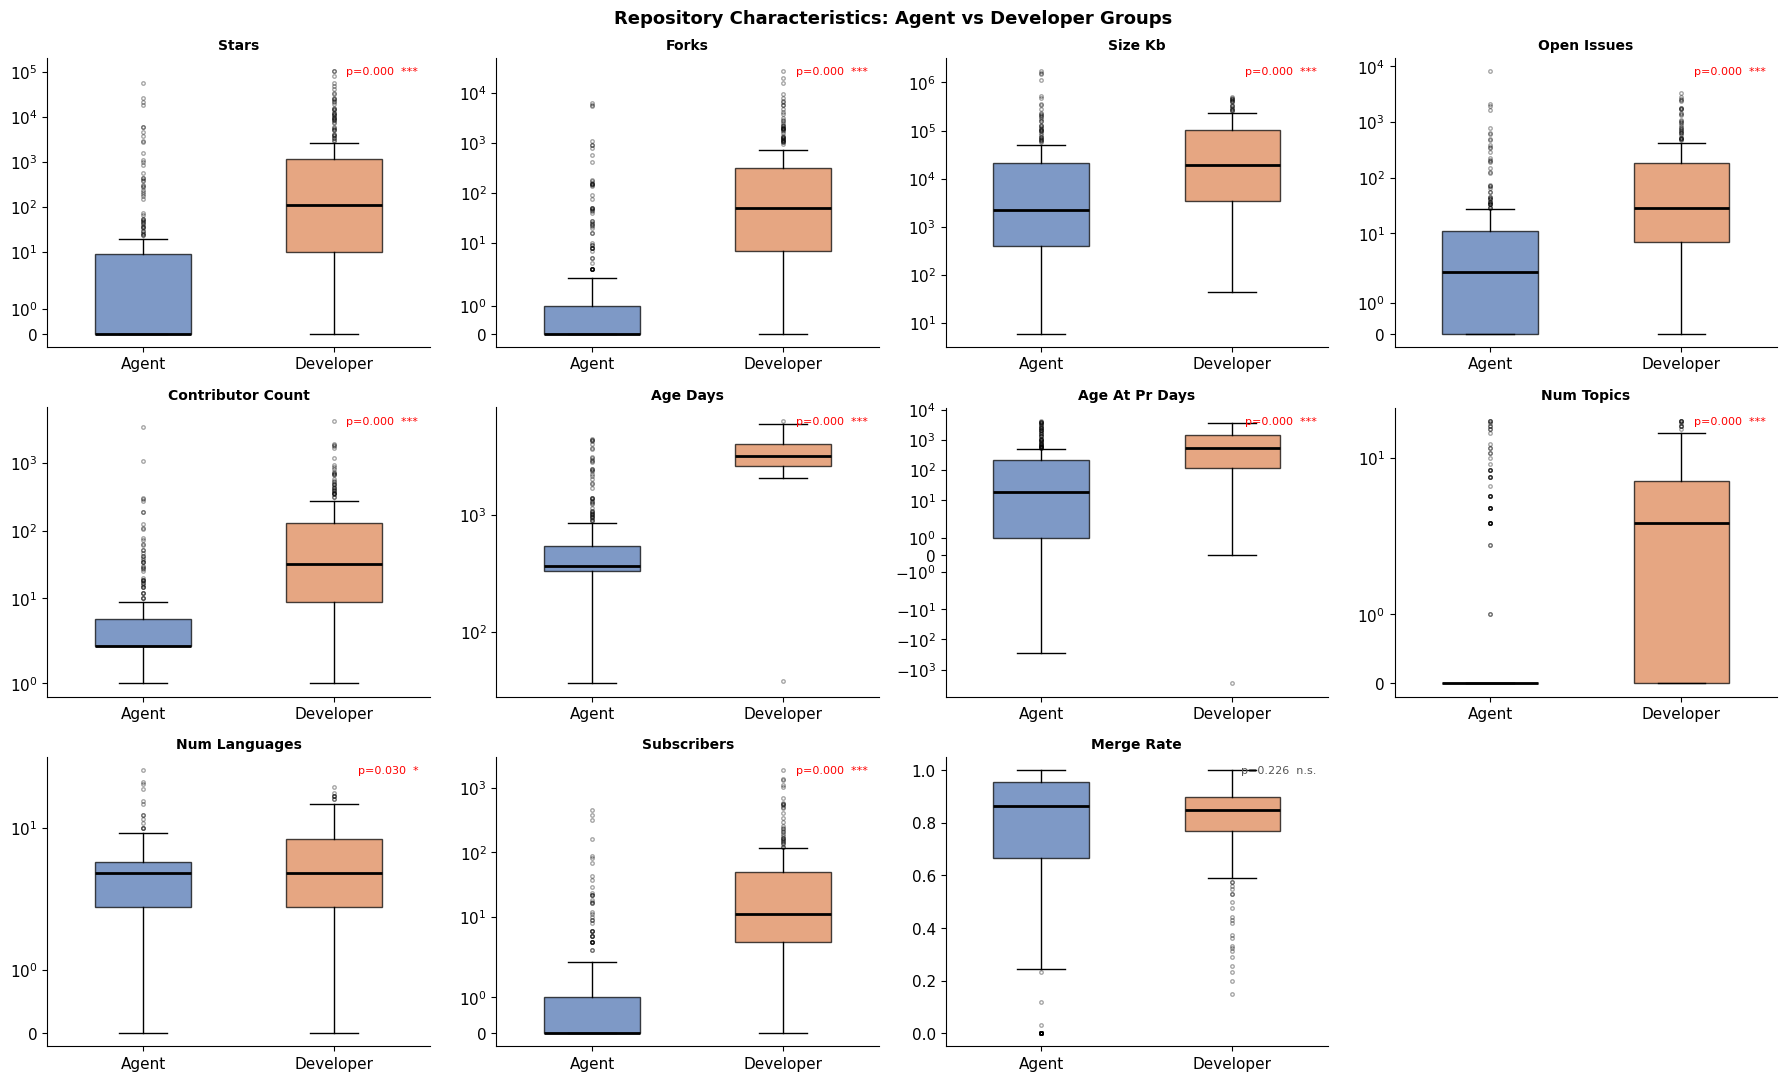

Saved → numeric_comparisons.png


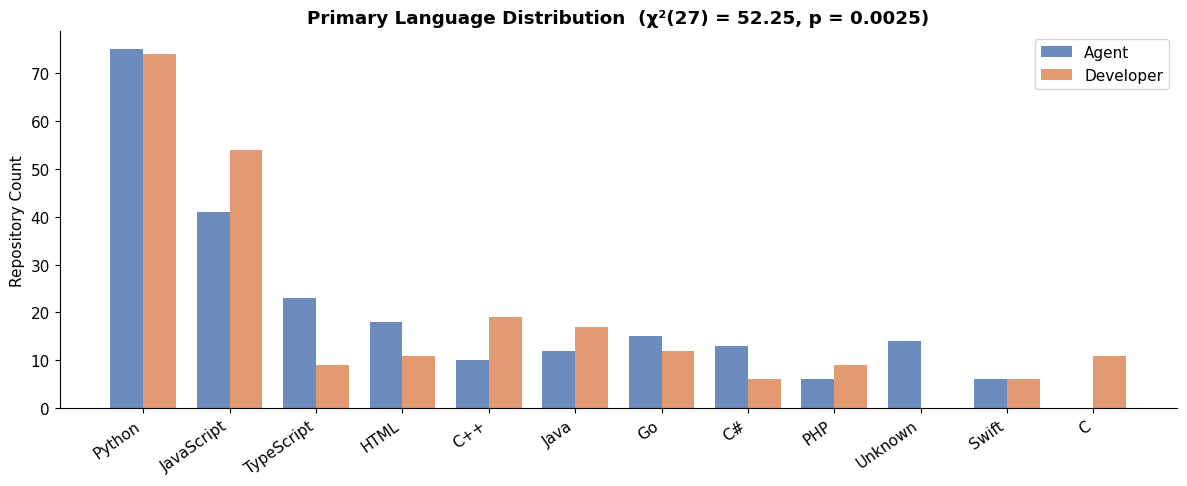

Saved → language_distribution.png

COMPARABILITY SUMMARY
  Agent group:      257 repositories
  Developer group:  251 repositories

  Numeric (Mann-Whitney U, two-sided, α = 0.05):
    Non-significant [1]: Merge Rate
    Significant     [10]: Stars, Forks, Size Kb, Open Issues, Contributor Count, Age Days, Age At Pr Days, Num Topics, Num Languages, Subscribers
    Sig. Bonferroni [9]: Stars, Forks, Size Kb, Open Issues, Contributor Count, Age Days, Age At Pr Days, Num Topics, Subscribers

  Language distribution: χ²(27) = 52.25, p = 0.0025  *

  ✗  Systematic differences found across multiple metrics.
    Consider stratification or covariate control in the main analysis.


In [4]:

# ── Visualizations ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})
PALETTE = {'agent': '#4C72B0', 'developer': '#DD8452'}


# 1. Numeric comparisons — 3×4 box-plot grid (11 metrics, last cell hidden) ──
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for ax, col in zip(axes, NUMERIC):
    a_vals = df_agent_meta[col].dropna()
    d_vals = df_dev_meta[col].dropna()

    bp = ax.boxplot(
        [a_vals, d_vals],
        labels=['Agent', 'Developer'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2.5, alpha=0.35, linestyle='none'),
        widths=0.5,
    )
    for patch, color in zip(bp['boxes'], PALETTE.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.72)

    ax.set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=10)
    # merge_rate is [0,1] — linear scale; everything else symlog
    if col != 'merge_rate':
        ax.set_yscale('symlog')

    row = df_stats[df_stats['Metric'] == col.replace('_', ' ').title()].iloc[0]
    p = row['p (MWU)']
    sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    ax.text(0.97, 0.97, f'p={p:.3f}  {sig_str}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='red' if p < 0.05 else '#555')

for ax in axes[len(NUMERIC):]:
    ax.set_visible(False)

fig.suptitle('Repository Characteristics: Agent vs Developer Groups',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(Path(OUT_DIR) / 'numeric_comparisons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → numeric_comparisons.png")


# 2. Primary language distribution ────────────────────────────────────────────
top_n = 12
lang_df = (
    pd.concat([
        df_agent_meta['primary_language'].value_counts().head(top_n).rename('Agent'),
        df_dev_meta['primary_language'].value_counts().head(top_n).rename('Developer'),
    ], axis=1)
    .fillna(0)
    .assign(_total=lambda x: x.sum(axis=1))
    .sort_values('_total', ascending=False)
    .drop(columns='_total')
    .head(top_n)
)

fig2, ax2 = plt.subplots(figsize=(12, 5))
x = np.arange(len(lang_df))
w = 0.38
ax2.bar(x - w/2, lang_df['Agent'],     width=w, color=PALETTE['agent'],     alpha=0.82, label='Agent')
ax2.bar(x + w/2, lang_df['Developer'], width=w, color=PALETTE['developer'], alpha=0.82, label='Developer')
ax2.set_xticks(x)
ax2.set_xticklabels(lang_df.index, rotation=35, ha='right')
ax2.set_ylabel('Repository Count')
ax2.set_title(
    f'Primary Language Distribution  (χ²({dof_lang}) = {chi2_lang:.2f}, p = {p_lang:.4f})',
    fontweight='bold',
)
ax2.legend()
fig2.tight_layout()
fig2.savefig(Path(OUT_DIR) / 'language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → language_distribution.png")


# ── Summary ───────────────────────────────────────────────────────────────────
sig_metrics  = df_stats[df_stats['sig']]['Metric'].tolist()
nsig_metrics = df_stats[~df_stats['sig']]['Metric'].tolist()
sig_bonf     = df_stats[df_stats['sig_bonf']]['Metric'].tolist()

print("\n" + "=" * 65)
print("COMPARABILITY SUMMARY")
print("=" * 65)
print(f"  Agent group:     {len(df_agent_meta):>4} repositories")
print(f"  Developer group: {len(df_dev_meta):>4} repositories")
print()
print(f"  Numeric (Mann-Whitney U, two-sided, α = 0.05):")
print(f"    Non-significant [{len(nsig_metrics)}]: {', '.join(nsig_metrics)}")
print(f"    Significant     [{len(sig_metrics)}]: {', '.join(sig_metrics) or 'none'}")
print(f"    Sig. Bonferroni [{len(sig_bonf)}]: {', '.join(sig_bonf) or 'none'}")
print()
print(f"  Language distribution: χ²({dof_lang}) = {chi2_lang:.2f}, "
      f"p = {p_lang:.4f}  {'*' if p_lang < 0.05 else '(n.s.)'}")
print()
n_sig_total = len(sig_bonf) + int(p_lang < 0.05)
if n_sig_total == 0:
    print("  ✓ No statistically significant differences after correction.")
    print("    The two groups are comparable as repository populations.")
elif n_sig_total <= 2:
    print("  ⚠  Minor differences detected in a small number of metrics.")
    print("    Groups are broadly comparable; note differences as limitations.")
else:
    print("  ✗  Systematic differences found across multiple metrics.")
    print("    Consider stratification or covariate control in the main analysis.")
